First, we have to import packages and load our data!

Kaggle has an API option, but its honestly just easier to download the file b/c its not too big

Sources:

Election dataset: https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/VOQCHQ 

Storms dataset: https://www.kaggle.com/datasets/brsdincer/natural-disaster-data-noaa-years 


In [ ]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import glob
import os
import re
import string
import plotnine
from plotnine import *


## sklearn imports
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler

## print mult things
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

Loading storms data is complicated: we have to read in a file for each year and then combine them all into one df

In [ ]:

folder = "storm_data"

csv_files = glob.glob(os.path.join(folder, "StormEvents_details-ftp_v1.0_*.csv"))

print("Found files:", csv_files)

dfs = []

for file in csv_files:   #this is from chatgpt, didn't learn it in class and I didnt want to do it manually
    print("Reading file:", file)
    df = pd.read_csv(file)
    if not df.empty:
        # Extract year from filename using regex
        match = re.search(r'd(\d{4})', os.path.basename(file))
        if match:
            year = int(match.group(1))
            df['year'] = year
            dfs.append(df)
        else:
            print("Year not found in filename:", file)
    else:
        print("Skipped empty file:", file)


storms = pd.concat(dfs, ignore_index=True)

print("Combined DataFrame shape:", storms.shape)
print("Years in data:", storms['year'].unique())

Loading Election data is much more simple, and we filter our storms data to just include counties

In [ ]:
elections = pd.read_csv("countypres_2000-2024.csv")

#only select storms that occured in counties 

storms_counties = storms[storms["CZ_TYPE"] == "C"]

#check to make sure
#print(storms_counties["CZ_TYPE"].value_counts())



Now, we have to deal with crop and property damage values: they are currently not in integer format and have to be handled with precision otherwise, we will incorporate incorrect inforamtion

We will also visualize the distribution of storm damage, as well as create a subset of high damage storms to analyze

In [ ]:
print(storms_counties["DAMAGE_PROPERTY"].value_counts())
#See the K vs. M

#we have to do this for two columns so may as well define a function

def damage_as_num(value):
    if pd.isna(value):
        return 0
    
    value = str(value).strip().upper()
    
    match = re.match(r'^([\d\.]+)\s*([KMB]?)$', value) #regex helped out by gpt, couldn't quite get it right 
    if not match:
        return 0 #choosing to turn NAs into 0s
    
    number, suffix = match.groups() #extract tuple from match group
    number = float(number)
    multiplier = {'K': 1000, 'M': 1000000, 'B': 1000000000}.get(suffix, 1) #dictionary for multiplier, match them to tuple
    
    return number * multiplier


storms_counties["property_damage_numeric"] = storms_counties['DAMAGE_PROPERTY'].apply(damage_as_num).astype(int)

#couple of checks
print(storms_counties["property_damage_numeric"].value_counts())

print(storms_counties["property_damage_numeric"].head())

print(storms_counties["DAMAGE_PROPERTY"].head())



storms_counties["crop_damage_numeric"] = storms_counties['DAMAGE_CROPS'].apply(damage_as_num).astype(int)


#lets visualize the costs using a boxplot

df_damage_vis = pd.melt(storms_counties,
                        value_vars=['property_damage_numeric', 'crop_damage_numeric'],
                        var_name= "Type_of_Damage",
                        value_name= "Value")


print(df_damage_vis.groupby("Type_of_Damage")["Value"].agg(["mean", "median"])) 

#We notice the zeros are really skewing our data. We want to focus on high-impact storms so we will drop rows with a value of zero
#in our visualization and statline, then do it for the parent dataframe further down

df_damage_vis_clean = df_damage_vis[df_damage_vis["Value"] > 0]

#HUGE difference


print(df_damage_vis_clean.groupby("Type_of_Damage")["Value"].agg(["mean", "median"])) 

plot = (
    ggplot(df_damage_vis_clean, aes(x='Type_of_Damage', y='Value'))
    + geom_boxplot()
    + scale_y_log10()
    + scale_x_discrete(labels= ["Crop Damage", "Property Damage"])  
    + labs(
        title="Distribution of damage caused by storms",
        x="Damage Type",
        y="Damage Cost"
    )
    + theme_minimal()
)

plot

storm_counties_nozerodmg = storms_counties[storms_counties["property_damage_numeric"] > 0]
storm_counties_nozerodmg = storms_counties[storms_counties["crop_damage_numeric"] > 0]


Now, lets clean up our election data to get the variable we want

In [ ]:
df_dem = elections.loc[elections['party'] == 'DEMOCRAT'].copy()

df_dem["percent"] = df_dem['candidatevotes'] / df_dem['totalvotes']



df_dem = df_dem[['year', 'state', 'county_fips', 'county_name', 'percent']]
df_dem = df_dem.sort_values(['county_fips', 'year'])

# Compute change from previous election (diff within each county)
df_dem['change_in_dem_vote_percent'] = df_dem.groupby('county_fips')['percent'].diff()


print(df_dem.head(10))


It gets tricky here. I think the next move is to split the elections dataset by year, and match the storms dataset in the same way

We will also create a column to merge on, namely the county_fips column. this has to be manually created for the storms dataset, and cleaned for the MIT dataset

In [ ]:

df_dem["county_fips_cleaned"] = df_dem['county_fips'].astype(str)


df_dem['county_fips_cleaned'] = df_dem['county_fips_cleaned'].str.replace(r'\.0$', '', regex=True)

#zero padding from stack
df_dem['county_fips_cleaned'] = df_dem['county_fips_cleaned'].str.zfill(5)

print(df_dem[['county_fips_cleaned']].head())


df_dem = df_dem[df_dem["year"] > 2000]

years = df_dem['year'].unique()


dfs_by_year = {year: df_dem[df_dem['year'] == year].copy() for year in years}


df_2004 = dfs_by_year[2004]
df_2008 = dfs_by_year[2008]
df_2012 = dfs_by_year[2012]
df_2016 = dfs_by_year[2016]
df_2020 = dfs_by_year[2020]
df_2024 = dfs_by_year[2024]






#For storms, its a bit more tricky, we have to group by election year, not just the year, so we use the yearmonth, and day column to parse out a date

#function to parse
def parse_year_month(value):
    match = re.match(r'(\d{4})(\d{2})', str(value))
    if match:
        year, month = match.groups()
        return int(year), int(month)
    else:
        return None, None
    


storm_counties_nozerodmg[["year", "month"]] = storm_counties_nozerodmg["BEGIN_YEARMONTH"].apply(lambda x: pd.Series(parse_year_month(x))) #ending bit is form gpt cuz i couldn't extract a tuple into 2 columns

storm_counties_nozerodmg["day"] = storm_counties_nozerodmg["BEGIN_DAY"]

storm_counties_nozerodmg["date"] = pd.to_datetime(storm_counties_nozerodmg[["year", "month", "day"]])


#Adding in cleaned county FIPS here, before we move on to grouping them

print(storm_counties_nozerodmg[['CZ_FIPS', "STATE_FIPS"]]) #stored as a string which is annoying
storm_counties_nozerodmg['STATE_FIPS'] = storm_counties_nozerodmg['STATE_FIPS'].astype(str)

storm_counties_nozerodmg['STATE_FIPS'] = (
    storm_counties_nozerodmg['STATE_FIPS']
    .str.replace(r'\.0$', '', regex=True)  
    .astype(int)                           
    .astype(str)                           
    .str.zfill(2)     
                      )                   
storm_counties_nozerodmg['STATE_FIPS'] = storm_counties_nozerodmg['STATE_FIPS'].astype(int)
storm_counties_nozerodmg['STATE_FIPS'] = storm_counties_nozerodmg['STATE_FIPS'].astype(str).str.zfill(2) #zero padding here and below just in case tbh
storm_counties_nozerodmg['CZ_FIPS'] = storm_counties_nozerodmg['CZ_FIPS'].astype(str).str.zfill(3)
storm_counties_nozerodmg['county_fips'] = storm_counties_nozerodmg['STATE_FIPS'] + storm_counties_nozerodmg['CZ_FIPS']

print(storm_counties_nozerodmg["county_fips"])




storms_2004 = storm_counties_nozerodmg[storm_counties_nozerodmg["date"] < '2004-11-02']

storms_2008 = storm_counties_nozerodmg[(storm_counties_nozerodmg["date"] > '2004-11-02') & (storm_counties_nozerodmg["date"] < '2008-11-04')]

storms_2012 = storm_counties_nozerodmg[(storm_counties_nozerodmg["date"] > '2008-11-04') & (storm_counties_nozerodmg["date"] < '2012-11-06')]

storms_2016 = storm_counties_nozerodmg[(storm_counties_nozerodmg["date"] > '2012-11-06') & (storm_counties_nozerodmg["date"] < '2016-11-08')]

storms_2020 = storm_counties_nozerodmg[(storm_counties_nozerodmg["date"] > '2016-11-08') & (storm_counties_nozerodmg["date"] < '2020-11-03')]

storms_2024 = storm_counties_nozerodmg[(storm_counties_nozerodmg["date"] > '2020-11-03') & (storm_counties_nozerodmg["date"] < '2024-11-05')]















We will merge each dataset to begin our initial visualization of first just tracking aggregate storm damage per county versus change in democratic votes

        BEGIN_YEARMONTH  BEGIN_DAY  BEGIN_TIME  END_YEARMONTH  END_DAY  \
185437           200502         23        1335         200502       23   
187524           200501          7           0         200501       11   
188155           200502         20        2245         200502       21   
188971           200501         12        2240         200501       12   
189468           200501          7         200         200501       11   

        END_TIME  EPISODE_ID  EVENT_ID       STATE STATE_FIPS  ...  \
185437      1335     1184398   5438153   LOUISIANA         22  ...   
187524      2300     1184791   5436692  CALIFORNIA         06  ...   
188155       600     1184980   5437243  CALIFORNIA         06  ...   
188971      2240     1184634   5438445    MICHIGAN         26  ...   
189468      1800     1184695   5438918  CALIFORNIA         06  ...   

                                        EPISODE_NARRATIVE  \
185437                                                NaN   
187524  A st

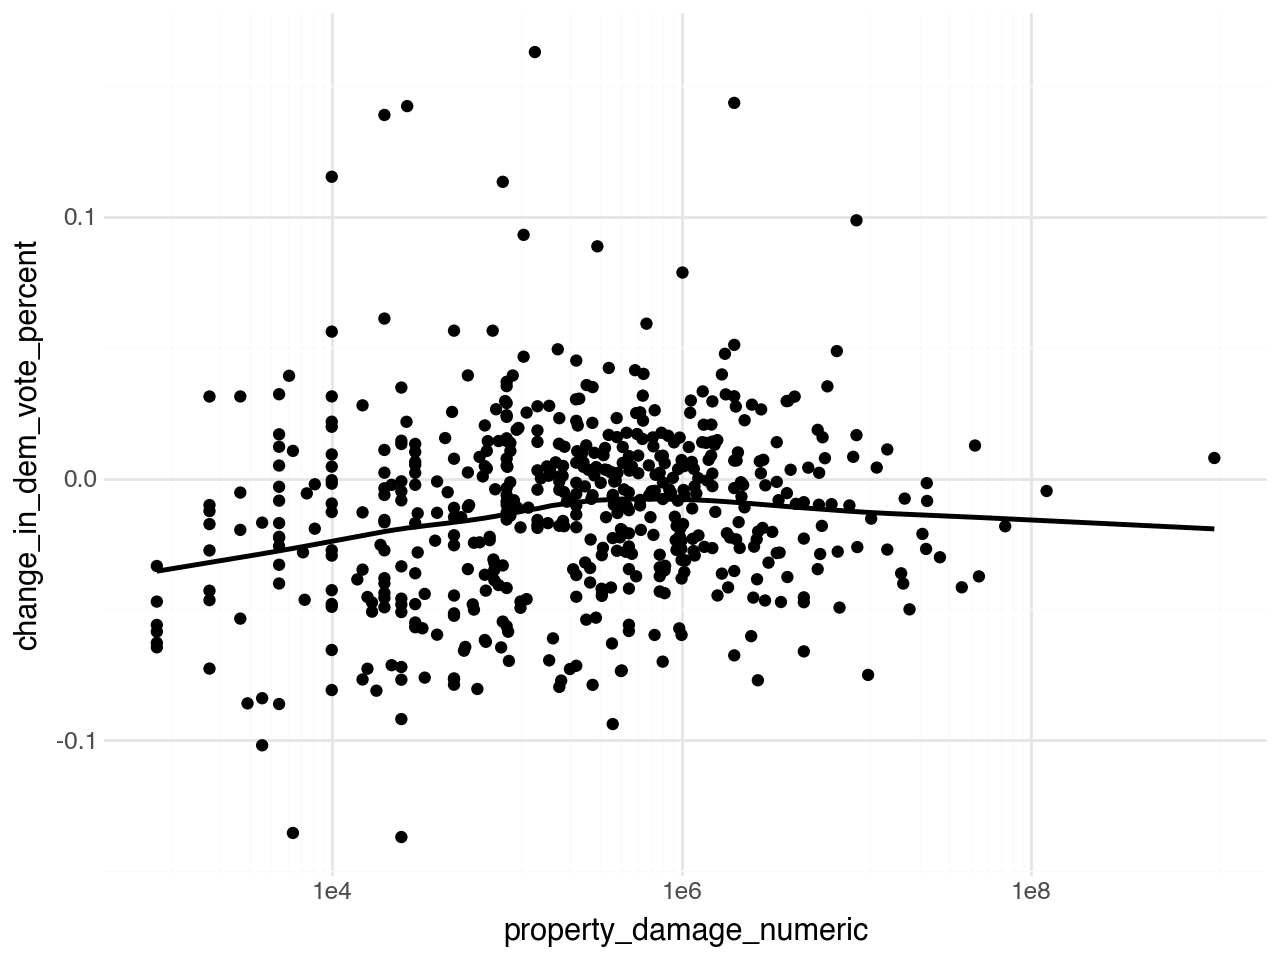

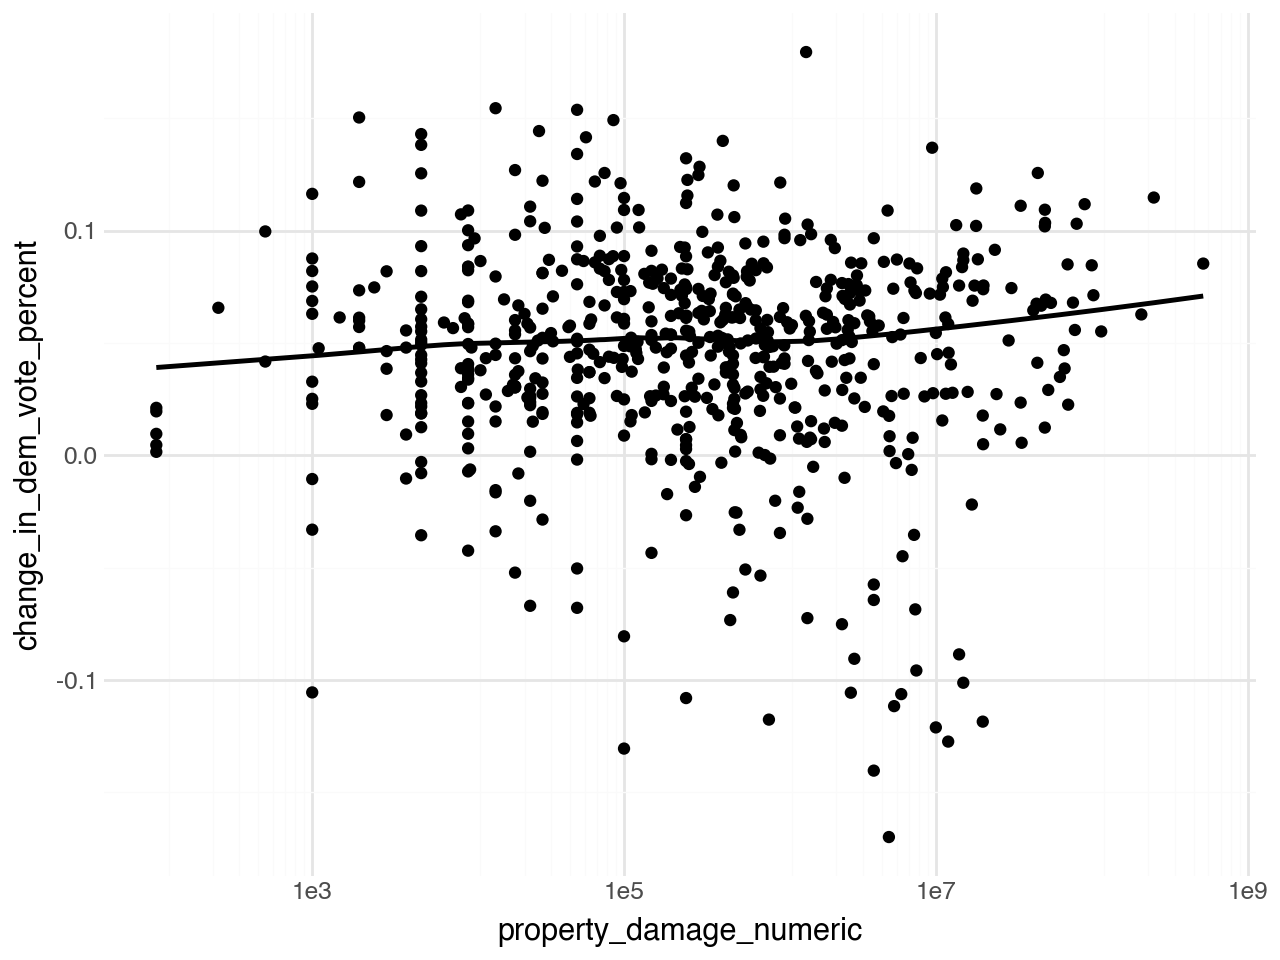

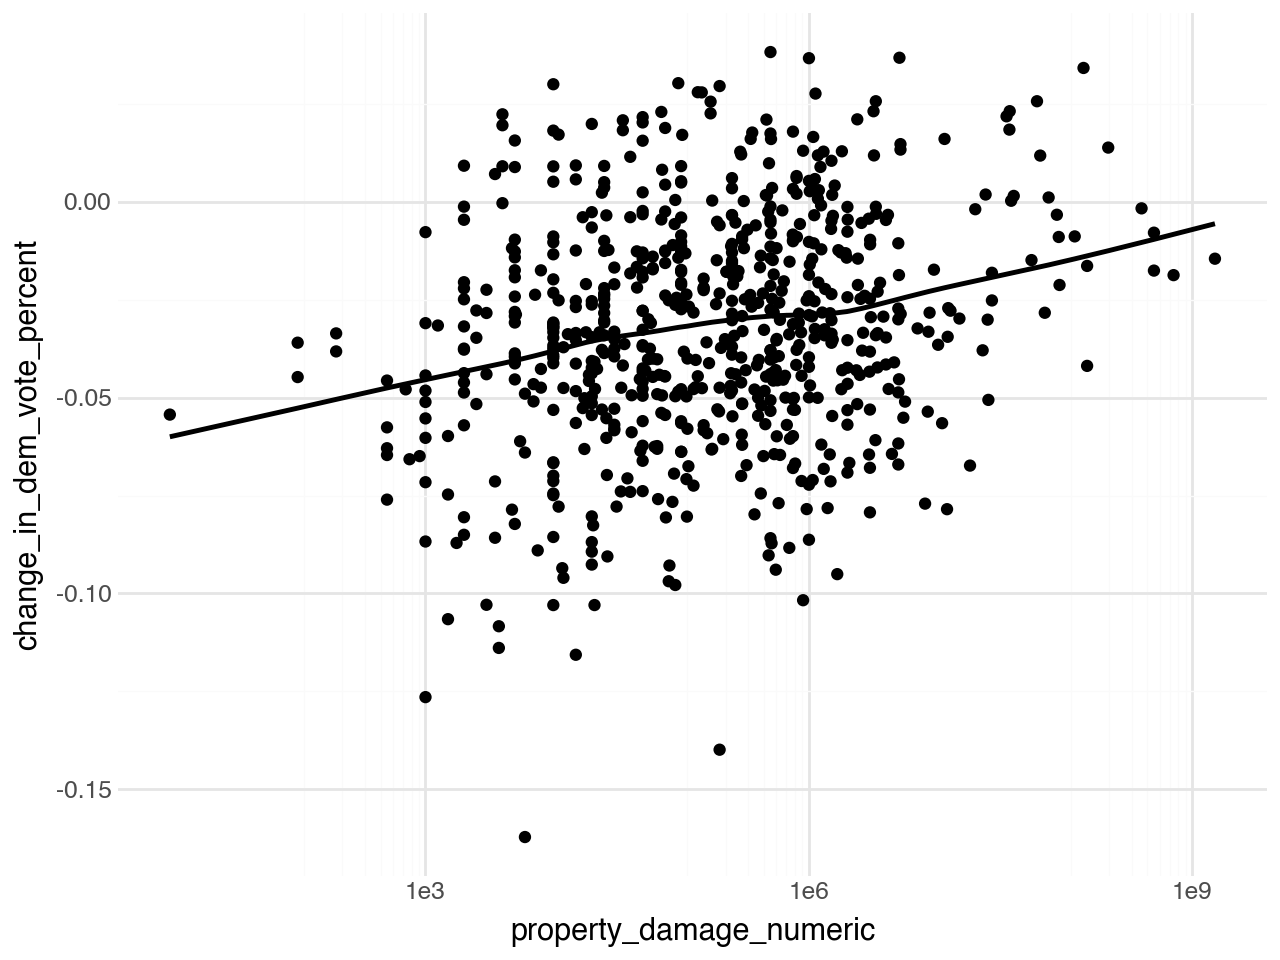

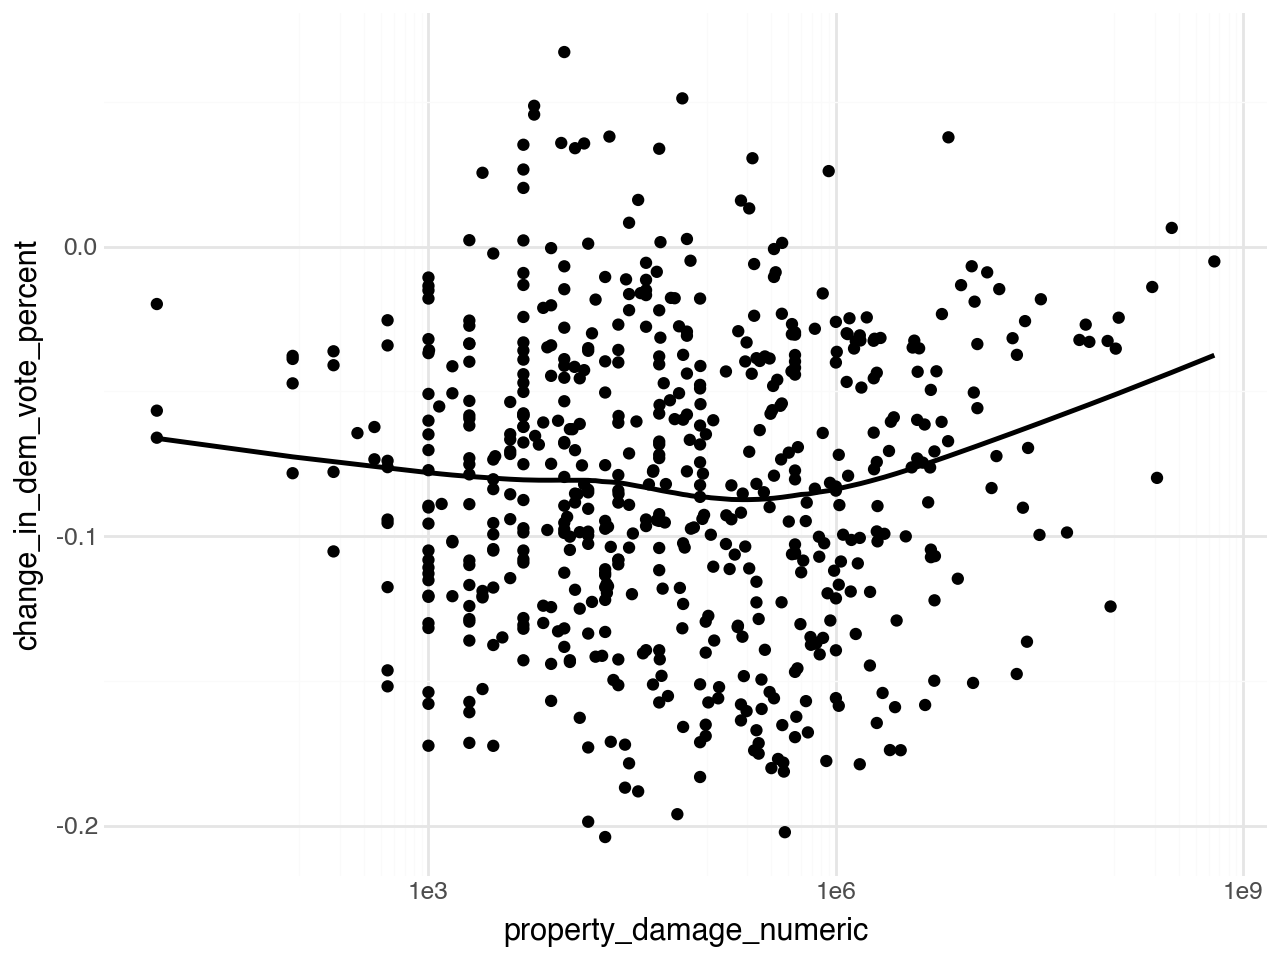

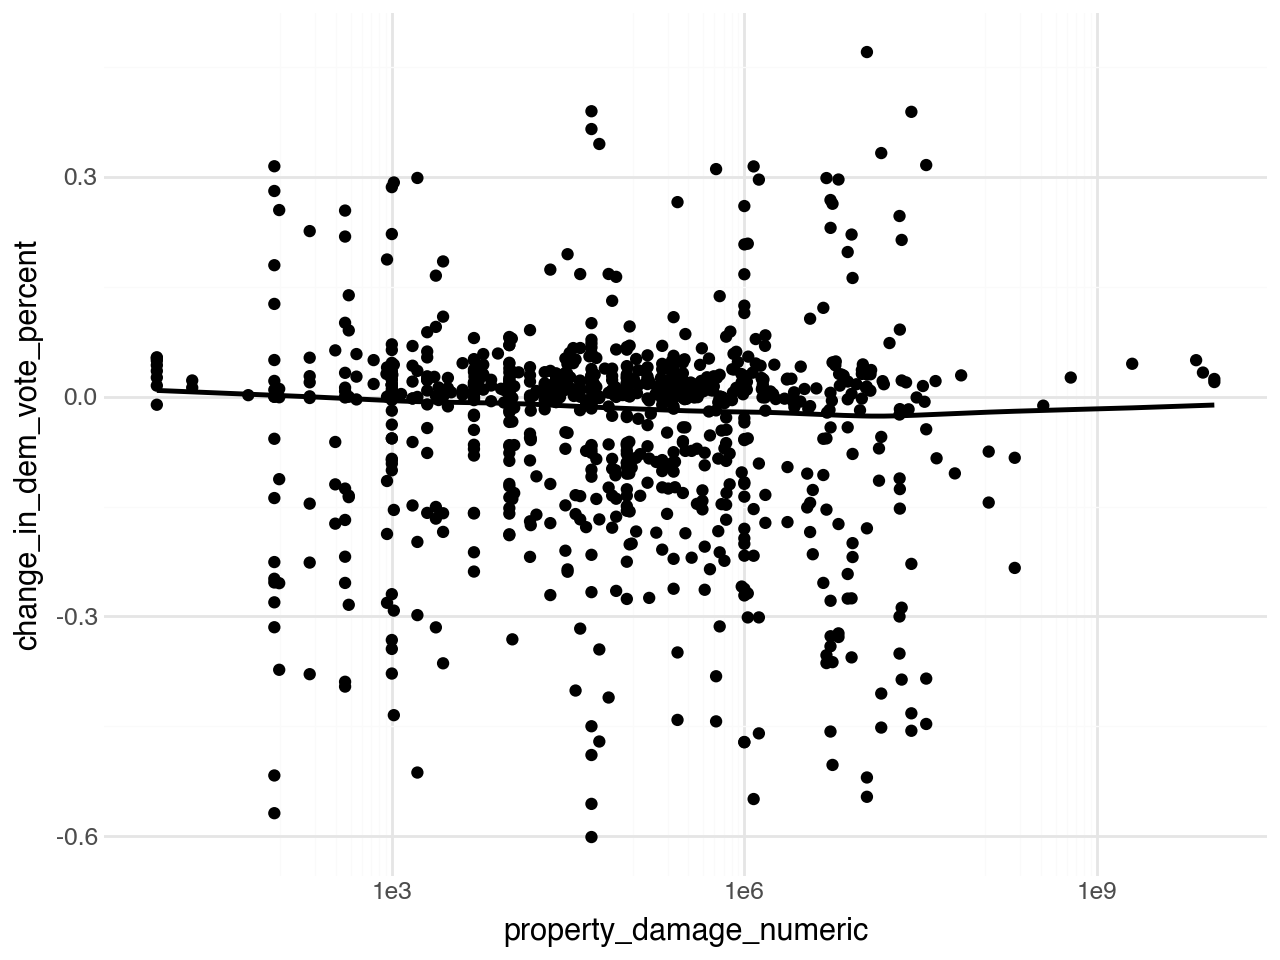

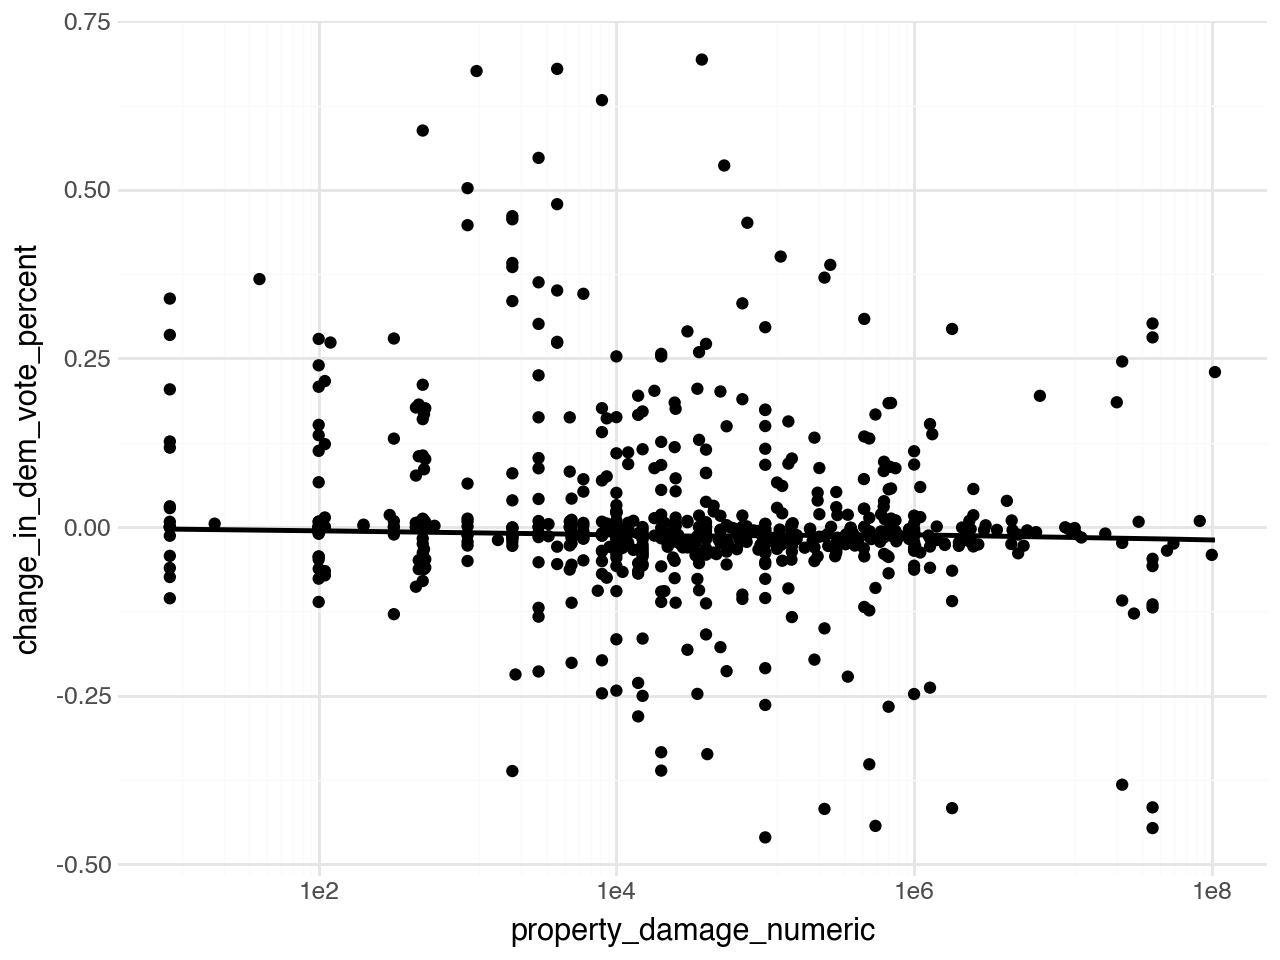

In [23]:

storms_prop_agg_2004 = storms_2004.groupby('county_fips', as_index=False)['property_damage_numeric'].sum()
storms_prop_agg_2008 = storms_2008.groupby('county_fips', as_index=False)['property_damage_numeric'].sum()
storms_prop_agg_2012 = storms_2012.groupby('county_fips', as_index=False)['property_damage_numeric'].sum()
storms_prop_agg_2016 = storms_2016.groupby('county_fips', as_index=False)['property_damage_numeric'].sum()
storms_prop_agg_2020 = storms_2020.groupby('county_fips', as_index=False)['property_damage_numeric'].sum()
storms_prop_agg_2024 = storms_2024.groupby('county_fips', as_index=False)['property_damage_numeric'].sum()

print(storms_2008.head())
print(storms_prop_agg_2012.head())



def merge_storms_elections(storms, elections):
    df_merged = pd.merge(
        storms,
        elections,
        how= "inner",
        left_on= "county_fips",
        right_on= "county_fips_cleaned"
    )
    
    return df_merged


property_damage_2004 = merge_storms_elections(storms_prop_agg_2004, df_2004)
property_damage_2008 = merge_storms_elections(storms_prop_agg_2008, df_2008)
property_damage_2012 = merge_storms_elections(storms_prop_agg_2012, df_2012)
property_damage_2016 = merge_storms_elections(storms_prop_agg_2016, df_2016)
property_damage_2020 = merge_storms_elections(storms_prop_agg_2020, df_2020)
property_damage_2024 = merge_storms_elections(storms_prop_agg_2024, df_2024)


print(property_damage_2008.head())


def initial_plot_function(df):
   
    df_filt = df[df["property_damage_numeric"] > 0]
    plot = (
    ggplot(df_filt, aes(x = "property_damage_numeric", y = "change_in_dem_vote_percent")) +
    geom_point() +
    geom_smooth() +
    scale_x_log10() +
    theme_minimal()
)
    return plot

plot_2004 = initial_plot_function(property_damage_2004)
plot_2004

plot_2008 = initial_plot_function(property_damage_2008)
plot_2008

plot_2012 = initial_plot_function(property_damage_2012)
plot_2012

plot_2016 = initial_plot_function(property_damage_2016)
plot_2016

plot_2020 = initial_plot_function(property_damage_2020)
plot_2020

plot_2024 = initial_plot_function(property_damage_2024)
plot_2024



Repeat prelim analysis for crop damage

In [ ]:

#aggregate on crops
crops_2004 = storms_2004.groupby('county_fips', as_index=False)['crop_damage_numeric'].sum()
crops_2008 = storms_2008.groupby('county_fips', as_index=False)['crop_damage_numeric'].sum()
crops_2012 = storms_2012.groupby('county_fips', as_index=False)['crop_damage_numeric'].sum()
crops_2016 = storms_2016.groupby('county_fips', as_index=False)['crop_damage_numeric'].sum()
crops_2020 = storms_2020.groupby('county_fips', as_index=False)['crop_damage_numeric'].sum()
crops_2024 = storms_2024.groupby('county_fips', as_index=False)['crop_damage_numeric'].sum()


#merge
crops_merged_2004 = merge_storms_elections(crops_2004, df_2004)
crops_merged_2008 = merge_storms_elections(crops_2008, df_2008)
crops_merged_2012 = merge_storms_elections(crops_2012, df_2012)
crops_merged_2016 = merge_storms_elections(crops_2016, df_2016)
crops_merged_2020 = merge_storms_elections(crops_2020, df_2020)
crops_merged_2024 = merge_storms_elections(crops_2024, df_2024)